# Data Analytics - Tech Challenge Fase 04 
**Objetivo:** Desenvolver um modelo de Machine Learning que auxilie médicos a prever o nível de obesidade de um paciente com base em seus hábitos e características físicas.

In [1]:
# Bibliotecas essenciais para manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Ferramentas para medir a qualidade do modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


In [2]:
#Leitura do arquivo direto do repositório do Github
URL_DADOS = (
    "https://raw.githubusercontent.com/jnssena/tech_challenge_4"
    "/main/Referencias_Atividade/Obesity.csv"
)

df = pd.read_csv(URL_DADOS)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()


Linhas: 2111
Colunas: 17


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:

print("Estrutura do Dataframe:")
df.info()


Estrutura do Dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float6

### Verificação de valores nulos


In [4]:
nulos = df.isnull().sum()

if nulos.sum() == 0:
    print("Nenhum valor nulo encontrado!")
else:
    print("Valores nulos encontrados:")
    print(nulos[nulos > 0])


Nenhum valor nulo encontrado!


### Distribuição do Nivel de Obesidade

Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


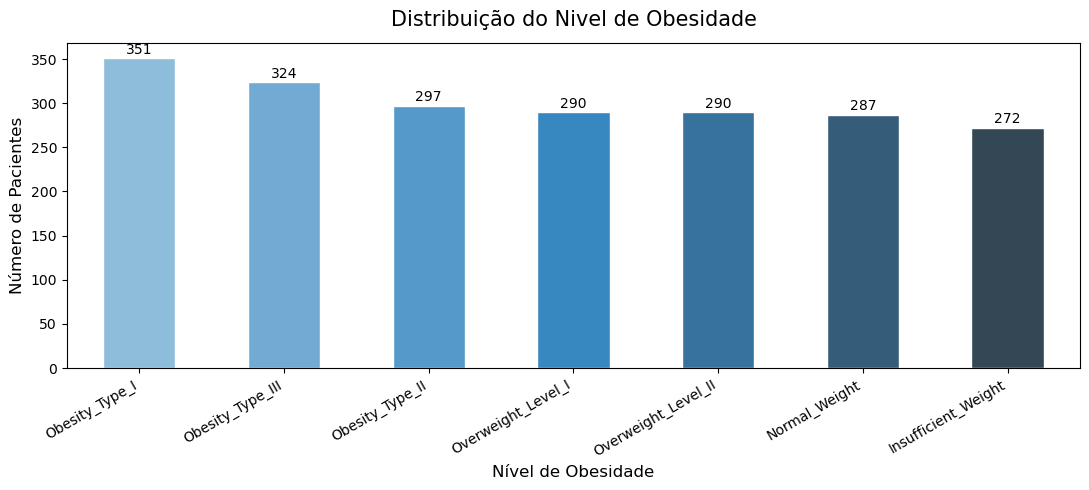

In [5]:
COLUNA_ALVO = 'Obesity'  # Coluna que queremos prever

contagem = df[COLUNA_ALVO].value_counts()
print(contagem)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(11, 5))
cores = sns.color_palette("Blues_d", len(contagem))
contagem.plot(kind='bar', color=cores, edgecolor='white', ax=ax)
ax.set_title('Distribuição do Nivel de Obesidade', fontsize=15, pad=12)
ax.set_xlabel('Nível de Obesidade', fontsize=12)
ax.set_ylabel('Número de Pacientes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Adiciona os valores em cima de cada barra
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            int(bar.get_height()),
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### Estatísticas descritivas das variáveis numéricas


In [6]:
df.describe().round(2).T  # .T transpõe a tabela (fica mais legível)

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.31,6.35,14.00,19.95,22.78,26.00,61.00
Height,2111.0,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2111.0,86.59,26.19,39.00,65.47,83.00,107.43,173.00
FCVC,2111.0,2.42,0.53,1.00,2.00,2.39,3.00,3.00
NCP,2111.0,2.69,0.78,1.00,2.66,3.00,3.00,4.00
CH2O,2111.0,2.01,0.61,1.00,1.58,2.00,2.48,3.00
FAF,2111.0,1.01,0.85,0.00,0.12,1.00,1.67,3.00
TUE,2111.0,0.66,0.61,0.00,0.00,0.63,1.00,2.00


### Gráfico de Correlação

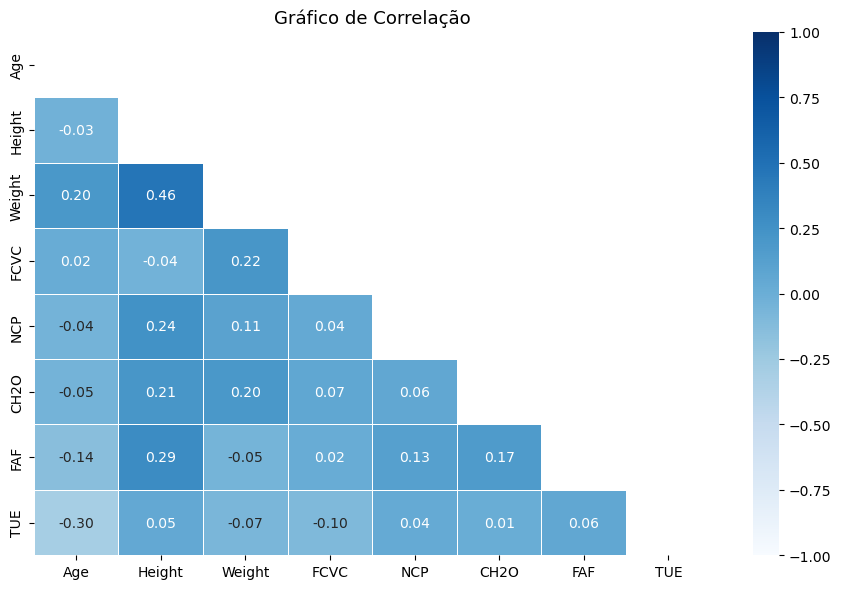

In [7]:
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(9, 6))
corr = df[colunas_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Oculta a metade espelhada
sns.heatmap(corr, mask=mask, cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Gráfico de Correlação', fontsize=13)
plt.tight_layout()
plt.show()


### Label Encoding das variáveis categóricas

In [8]:
df_modelo = df.copy()

# Identificar colunas de texto (categóricas)
colunas_categoricas = df_modelo.select_dtypes(include='object').columns.tolist()
colunas_features_cat = [c for c in colunas_categoricas if c != COLUNA_ALVO]

print(f"Colunas categóricas (features): {colunas_features_cat}")
print(f"Coluna alvo: {COLUNA_ALVO}")

# Dicionário para guardar todos os encoders
encoders = {}

# Encoding das features categóricas
for col in colunas_features_cat:
    le = LabelEncoder()
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    encoders[col] = le  # Guarda o encoder desta coluna

# Encoding separado do target
le_target = LabelEncoder()
df_modelo[COLUNA_ALVO] = le_target.fit_transform(df_modelo[COLUNA_ALVO].astype(str))
encoders[COLUNA_ALVO] = le_target

print(f"\nClasses do target (números → nomes):")
for i, classe in enumerate(le_target.classes_):
    print(f"  {i} → {classe}")


Colunas categóricas (features): ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Coluna alvo: Obesity

Classes do target (números → nomes):
  0 → Insufficient_Weight
  1 → Normal_Weight
  2 → Obesity_Type_I
  3 → Obesity_Type_II
  4 → Obesity_Type_III
  5 → Overweight_Level_I
  6 → Overweight_Level_II


### Separação em Features (X) e Target (y)


In [9]:
X = df_modelo.drop(columns=[COLUNA_ALVO])  # Tudo exceto a coluna alvo
y = df_modelo[COLUNA_ALVO]                 # Só a coluna alvo

print(f"\nFeatures utilizadas:")
for col in X.columns:
    print(f"  • {col}")


Features utilizadas:
  • Gender
  • Age
  • Height
  • Weight
  • family_history
  • FAVC
  • FCVC
  • NCP
  • CAEC
  • SMOKE
  • CH2O
  • SCC
  • FAF
  • TUE
  • CALC
  • MTRANS


### Treino e Teste


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para teste
    random_state=42,     # Semente aleatória
    stratify=y           # Mantém proporção das classes em treino e teste
)


### Definição dos Modelos via Pipeline

In [11]:
# Definição dos modelos — cada um dentro de um Pipeline com normalização
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),          # Passo 1: normaliza os dados
        ("modelo", LogisticRegression(         # Passo 2: treina o modelo
            max_iter=1000,
            random_state=42
        ))
    ]),
    "Árvore de Decisão": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", RandomForestClassifier(
            n_estimators=100,   # 100 árvores no ensemble
            random_state=42
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),
    "KNN (K-Vizinhos)": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5))
    ]),
}

### Resultado de cada Modelo

In [12]:
# Validação cruzada estratificada (mantém proporção das classes em cada fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}

for nome, pipeline in modelos.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv,
        scoring='accuracy'
    )
    resultados[nome] = {"media": scores.mean(), "std": scores.std(), "scores": scores}
    print(f"  {nome:25s} → {scores.mean():.4f} ± {scores.std():.4f}")

  Regressão Logística       → 0.8679 ± 0.0179
  Árvore de Decisão         → 0.9206 ± 0.0140
  Random Forest             → 0.9467 ± 0.0115
  Gradient Boosting         → 0.9656 ± 0.0081
  KNN (K-Vizinhos)          → 0.7956 ± 0.0128


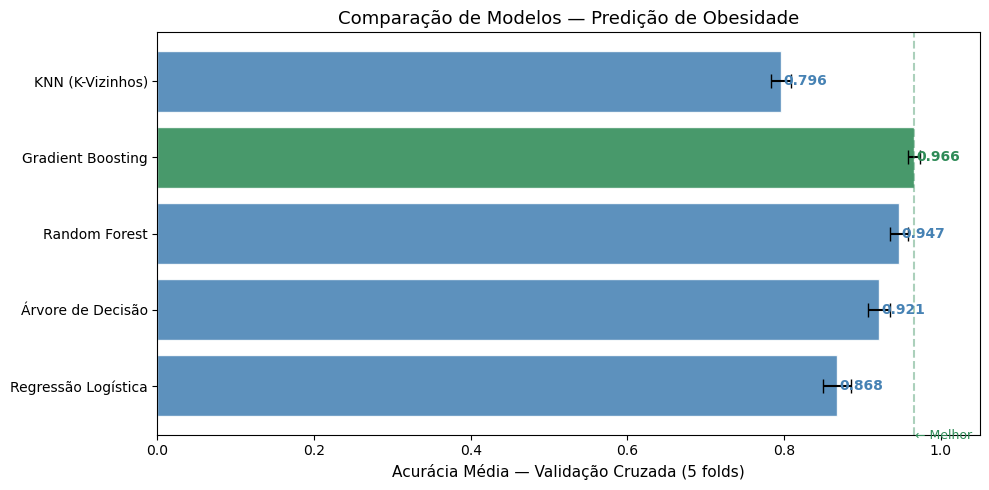

In [13]:
# Gráfico comparativo dos modelos
nomes   = list(resultados.keys())
medias  = [resultados[n]['media'] for n in nomes]
desvios = [resultados[n]['std']   for n in nomes]
melhor_idx = int(np.argmax(medias))

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['seagreen' if i == melhor_idx else 'steelblue' for i in range(len(nomes))]
bars = ax.barh(nomes, medias, xerr=desvios, color=cores,
               edgecolor='white', capsize=5, alpha=0.88)

# Anota o valor em cada barra
for i, (bar, media) in enumerate(zip(bars, medias)):
    ax.text(media + 0.003, bar.get_y() + bar.get_height()/2,
            f'{media:.3f}', va='center', fontsize=10,
            color='seagreen' if i == melhor_idx else 'steelblue', fontweight='bold')

ax.set_xlabel('Acurácia Média — Validação Cruzada (5 folds)', fontsize=11)
ax.set_title('Comparação de Modelos — Predição de Obesidade', fontsize=13)
ax.set_xlim(0, 1.05)
ax.axvline(x=max(medias), color='seagreen', linestyle='--', alpha=0.4)
ax.text(max(medias)+0.001, -0.7, '← Melhor', color='seagreen', fontsize=9)
plt.tight_layout()
plt.show()


### Treinamento e Avaliação do Melhor Modelo


In [14]:
# Seleciona automaticamente o melhor modelo pela maior acurácia média
nome_melhor = max(resultados, key=lambda n: resultados[n]['media'])
modelo_final = modelos[nome_melhor]

print(f"Melhor modelo: {nome_melhor}")
print(f"Acurácia: {resultados[nome_melhor]['media']:.4f} "
      f"(± {resultados[nome_melhor]['std']:.4f})")

# Treina no conjunto completo de treino
modelo_final.fit(X_train, y_train)

Melhor modelo: Gradient Boosting
Acurácia: 0.9656 (± 0.0081)


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', GradientBoostingClassifier(random_state=42))])

### Avaliação do Conjunto de Teste

In [15]:
y_pred = modelo_final.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print(f"  Acurácia  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.1f}%)")

# Relatório por classe mostra precisão/recall de cada nível de obesidade
print(classification_report(
    y_test, y_pred,
    target_names=le_target.classes_  # Converte números de volta para nomes
))


  Acurácia  : 0.9598  (96.0%)
  F1-Score  : 0.9603  (96.0%)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.85      0.98      0.91        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.91      0.92        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



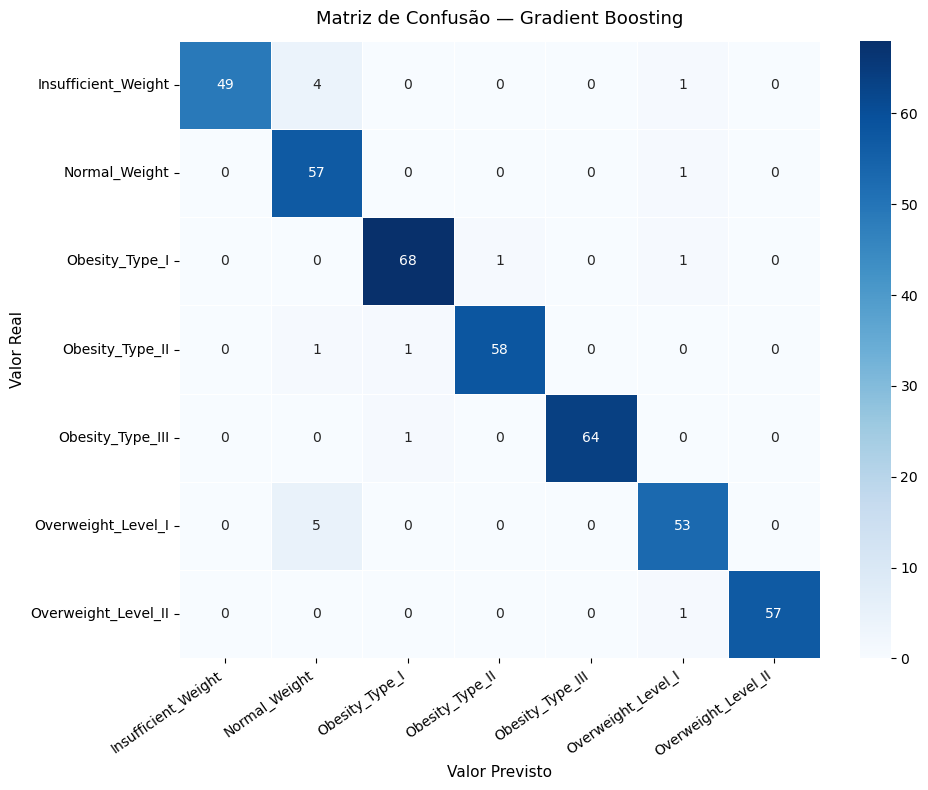

In [16]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f'Matriz de Confusão — {nome_melhor}', fontsize=13, pad=12)
ax.set_ylabel('Valor Real', fontsize=11)
ax.set_xlabel('Valor Previsto', fontsize=11)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
